# Notebook 05f — Rescue m=1 Population

## Purpose

The 05e smoothing notebook inadvertently demoted already-confirmed m=1 neurons by
treating visual ambiguity at R²<0.5 as evidence for m=0. That was backwards.
Ambiguity at 4.65°/pixel is the expected presentation for a genuine simple cell,
not a reason to demote.

This notebook:

1. **Restores** the 84-neuron m=1 population from the nb07+nb09 manual reviews
   (multistart + polarity fix, before 05e demotion)
2. **Rescues additional m=0 neurons** using Tony's two-stage smoothing approach —
   fits the automated-m=0 population with σ=1.0 and σ=1.5, flags those where
   m=1 now wins convincingly (ΔR²>0.05 with any sigma), and presents them for
   a quick visual review to accept as m=1
3. **Saves** a clean final population CSV

**Direction of travel:** smoothing is used to *add* neurons to m=1, never to remove them.

In [1]:
import sys, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import RidgeCV, Ridge
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.sparse_noise import (
    fit_rf_by_order,
    _build_design_matrix, _pixel_size, _LAMBDA_GRID,
    gaussian_deriv_m0, gaussian_deriv_m1, gaussian_deriv_m2,
)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
print('Imports OK')

Imports OK


In [9]:
# ---------------------------------------------------------------------------
# batch_get_rf_maps_safe — identical to nb05d
# ---------------------------------------------------------------------------
def batch_get_rf_maps_safe(dataset, requested_ids,
                            n_lags=8, response_delay=4, response_window=5):
    exp_cells = list(dataset.get_cell_specimen_ids())
    req_set   = set(int(c) for c in requested_ids)
    valid_ids = [c for c in exp_cells if c in req_set]
    if not valid_ids:
        raise ValueError('No requested cell_ids found.')
    stim_name = next((s for s in dataset.list_stimuli() if 'sparse_noise' in s), None)
    if not stim_name:
        raise ValueError('No sparse noise stimulus.')
    stim_table = dataset.get_stimulus_table(stim_name)
    tr         = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stim_name)
    template   = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix_size        = _pixel_size(stim_name)
    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)
    _, all_dff    = dataset.get_dff_traces(cell_specimen_ids=valid_ids)
    n_cells, n_tp = all_dff.shape
    X = _build_design_matrix(template, frame_indices, on_val, off_val,
                              grid_h, grid_w, n_lags)
    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)
    frame_valid  = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit, Y_fit = X[frame_valid].astype(np.float64), Y[frame_valid]
    if X_fit.shape[0] < 20:
        raise ValueError('Too few presentations.')
    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None,
                      fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)
    rf_out = {}
    for i, cid in enumerate(valid_ids):
        strf     = W[i].reshape(n_lags, grid_h, grid_w)
        best_lag = int(np.argmax([np.abs(strf[l]).max() for l in range(n_lags)]))
        rf_out[cid] = (strf[best_lag], pix_size)
    return rf_out

print('batch_get_rf_maps_safe defined')

batch_get_rf_maps_safe defined


In [2]:
# ---------------------------------------------------------------------------
# Paths — same as nb05d
# ---------------------------------------------------------------------------
base_dir    = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir   = base_dir / 'data' / 'cache'
lists_dir   = base_dir / 'data' / 'experiment_lists'
outputs_dir = base_dir / 'outputs' / 'rf_params'

nb05d_dir = outputs_dir / 'order_full_v2'   # v2 rerun CSVs
nb07_dir  = outputs_dir / 'order_full'       # nb07 manual judgements
nb09_dir  = outputs_dir / 'nb09'             # nb09 manual judgements

# Input: v2 combined CSV (before any 05e demotion)
V2_CSV = nb05d_dir / 'rf_params_order_v2_all_containers.csv'

# Outputs
RESCUE_JUDGEMENT_CSV = nb05d_dir / 'rescue_review_judgements.csv'
FINAL_CSV            = nb05d_dir / 'rf_params_final.csv'

boc = BrainObservatoryCache(manifest_file=str(cache_dir / 'manifest.json'))

batch_df       = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
verify_df      = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded     = set(verify_df[verify_df['exists']]['experiment_id'].tolist())
container_meta = pd.read_csv(lists_dir / 'container_neuron_counts.csv')
complete_ids   = set(container_meta['container_id'].tolist())

session_c = batch_df[
    batch_df['session_type'].str.contains('C') &
    batch_df['id'].isin(downloaded) &
    batch_df['experiment_container_id'].isin(complete_ids)
].copy()
container_to_exp = dict(zip(session_c['experiment_container_id'], session_c['id']))
print(f'Containers: {len(container_to_exp)}')
assert V2_CSV.exists(), f'V2 CSV not found at {V2_CSV} — check path'

Containers: 17


In [17]:
# ---------------------------------------------------------------------------
# STEP 1: Restore m=1 population from all manual review passes
# ---------------------------------------------------------------------------
all_df = pd.read_csv(V2_CSV)
for col in ['sigma','theta','kappa','r_squared','r2_m0','r2_m1','r2_m2',
            'delta_r2_vs_m0','r2_improvement','phi','phi_confidence',
            'theta_hybrid','sigma_x','sigma_y','cortex_x_um','cortex_y_um']:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

# Pass 1: nb07 as protected base — m=1 calls here cannot be demoted
judged      = {}
nb07_m1_ids = set()
nb07_path   = nb07_dir / 'manual_m_judgements.csv'
if nb07_path.exists():
    jdf = pd.read_csv(nb07_path)
    jdf = jdf[jdf['m_manual'] >= 0]
    for _, r in jdf.iterrows():
        judged[int(r['cell_id'])] = int(r['m_manual'])
        if int(r['m_manual']) == 1:
            nb07_m1_ids.add(int(r['cell_id']))
    print(f'nb07: {len(jdf)} judgements  ({len(nb07_m1_ids)} m=1 protected)')

# Pass 2: later reviews — cannot demote a nb07-confirmed m=1
for path, label in [
    (nb09_dir  / 'nb09_review_judgements.csv',       'nb09'),
    (nb05d_dir / 'targeted_review_judgements.csv',   'targeted'),
    (nb05d_dir / 'unreviewed_m1_judgements.csv',     'unreviewed_m1'),
    (nb05d_dir / 'rescue_review_judgements.csv',     'rescue'),        # future
]:
    if not path.exists():
        print(f'  {label}: not found — skipping')
        continue
    jdf     = pd.read_csv(path)
    jdf     = jdf[jdf['m_manual'] >= 0]
    applied = skipped = 0
    for _, r in jdf.iterrows():
        cid   = int(r['cell_id'])
        m_new = int(r['m_manual'])
        if cid in nb07_m1_ids and m_new == 0:
            skipped += 1
            continue
        judged[cid] = m_new
        applied += 1
    print(f'{label}: {applied} applied, {skipped} skipped (protected nb07 m=1)')

n_m1 = sum(1 for v in judged.values() if v == 1)
print(f'\nTotal judged: {len(judged)}  |  m=1 in judged: {n_m1}')

# m_final: manual where judged, else automated v2
all_df['m_manual']         = all_df['cell_id'].map(judged)
all_df['manually_verified'] = all_df['cell_id'].isin(judged)
all_df['m_final'] = np.where(
    all_df['m_manual'].notna(),
    all_df['m_manual'],
    all_df['derivative_order']
).astype(int)

# Auto-demote unreviewed m=2 with marginal ΔR²
if 'delta_r2_vs_m0' in all_df.columns:
    demote = (
        (all_df['m_final'] == 2) &
        (~all_df['manually_verified']) &
        (all_df['delta_r2_vs_m0'] < 0.10)
    )
    all_df.loc[demote, 'm_final'] = 0
    print(f'Auto-demoted {demote.sum()} unreviewed m=2 → m=0')

m1 = all_df[all_df['m_final'] == 1]
m1_verified = m1[m1['manually_verified']]
m1_auto     = m1[~m1['manually_verified']]

print(f'\nm_final breakdown:')
print(all_df['m_final'].value_counts().sort_index())
print(f'\nm=1 total:              {len(m1)}')
print(f'  manually verified:    {len(m1_verified)}')
print(f'  automated (unreviewed): {len(m1_auto)}')

nb07: 225 judgements  (13 m=1 protected)
nb09: 111 applied, 1 skipped (protected nb07 m=1)
targeted: 57 applied, 0 skipped (protected nb07 m=1)
unreviewed_m1: 1 applied, 0 skipped (protected nb07 m=1)
  rescue: not found — skipping

Total judged: 383  |  m=1 in judged: 31
Auto-demoted 102 unreviewed m=2 → m=0

m_final breakdown:
0    984
1     31
2      2
Name: m_final, dtype: int64

m=1 total:              31
  manually verified:    31
  automated (unreviewed): 0


In [6]:
# ---------------------------------------------------------------------------
# Cell 3b — Identify unreviewed automated m=1 neurons
# ---------------------------------------------------------------------------
already_reviewed = set(judged.keys())

unreviewed_m1 = all_df[
    (all_df['derivative_order'] == 1) &          # v2 automated call = m=1
    (~all_df['cell_id'].isin(already_reviewed))  # never manually reviewed
].sort_values('r_squared', ascending=False).reset_index(drop=True).copy()

print(f'Unreviewed automated m=1 neurons: {len(unreviewed_m1)}')
print(f'R² range: {unreviewed_m1["r_squared"].min():.3f}–'
      f'{unreviewed_m1["r_squared"].max():.3f}')
print(f'ΔR² range: {unreviewed_m1["delta_r2_vs_m0"].min():.3f}–'
      f'{unreviewed_m1["delta_r2_vs_m0"].max():.3f}')
print(f'\nBreakdown by ΔR² band:')
bands = [(0.15, 999, 'strong (≥0.15)'),
         (0.10, 0.15, 'moderate (0.10–0.15)'),
         (0.05, 0.10, 'marginal (0.05–0.10)'),
         (0.00, 0.05, 'weak (<0.05)')]
for lo, hi, label in bands:
    n = ((unreviewed_m1['delta_r2_vs_m0'] >= lo) &
         (unreviewed_m1['delta_r2_vs_m0'] < hi)).sum()
    print(f'  {label}: {n}')

Unreviewed automated m=1 neurons: 1
R² range: 0.507–0.507
ΔR² range: 0.185–0.185

Breakdown by ΔR² band:
  strong (≥0.15): 1
  moderate (0.10–0.15): 0
  marginal (0.05–0.10): 0
  weak (<0.05): 0


In [10]:
# ---------------------------------------------------------------------------
# Cell 3c — Load RF maps for unreviewed m=1 neurons
# ---------------------------------------------------------------------------
unrev_rf_cache  = {}
unrev_ds_cache  = {}

by_container = unreviewed_m1.groupby('container_id')['cell_id'].apply(list).to_dict()
print(f'Loading {len(unreviewed_m1)} neurons across {len(by_container)} containers')

t_start = time.time()
for i, (container_id, cids) in enumerate(by_container.items()):
    if container_id not in container_to_exp:
        print(f'  [{i+1}/{len(by_container)}] {container_id}: skip')
        continue
    print(f'  [{i+1}/{len(by_container)}] Container {container_id} '
          f'({len(cids)} neurons) ...', end=' ', flush=True)
    try:
        if container_id not in unrev_ds_cache:
            unrev_ds_cache[container_id] = boc.get_ophys_experiment_data(
                container_to_exp[container_id])
        maps = batch_get_rf_maps_safe(unrev_ds_cache[container_id], cids)
        unrev_rf_cache.update(maps)
        print(f'{len(maps)} loaded  ({time.time()-t_start:.0f}s)')
    except Exception as e:
        print(f'FAIL — {e}')

unrev_review_df = unreviewed_m1[
    unreviewed_m1['cell_id'].isin(unrev_rf_cache)
].reset_index(drop=True)
print(f'\n{len(unrev_review_df)} neurons ready')

Loading 1 neurons across 1 containers
  [1/1] Container 511510855 (1 neurons) ... 1 loaded  (131s)

1 neurons ready


In [11]:
# ---------------------------------------------------------------------------
# Cell 3d — Judgement store for unreviewed m=1
# ---------------------------------------------------------------------------
UNREV_JUDGEMENT_CSV = nb05d_dir / 'unreviewed_m1_judgements.csv'

if UNREV_JUDGEMENT_CSV.exists():
    unrev_judged     = pd.read_csv(UNREV_JUDGEMENT_CSV)
    unrev_judged_ids = set(unrev_judged['cell_id'].tolist())
    print(f'Loaded {len(unrev_judged)} existing judgements')
else:
    unrev_judged     = pd.DataFrame(columns=['cell_id', 'm_manual', 'note'])
    unrev_judged_ids = set()
    print('Fresh judgement store.')


def _first_unrev_unjudged(start=0):
    for i in range(start, len(unrev_review_df)):
        if int(unrev_review_df.iloc[i]['cell_id']) not in unrev_judged_ids:
            return i
    return len(unrev_review_df) - 1


if 'UNREV_IDX' not in dir():
    UNREV_IDX = _first_unrev_unjudged()

print(f'To review: {len(unrev_review_df)}  |  '
      f'Done: {len(unrev_judged_ids)}  |  '
      f'Remaining: {len(unrev_review_df) - len(unrev_judged_ids)}')
print(f'Starting at: {UNREV_IDX}')

Fresh judgement store.
To review: 1  |  Done: 0  |  Remaining: 1
Starting at: 0


In [13]:
# ---------------------------------------------------------------------------
# Helpers — refit_all_orders + plot_neuron_review
# ---------------------------------------------------------------------------
_MODEL_FNS      = {0: gaussian_deriv_m0, 1: gaussian_deriv_m1, 2: gaussian_deriv_m2}
N_RANDOM_STARTS = 15
SMOOTH_SIGMA    = 0.75
DELTA_R2_THRESHOLD = 0.05

def refit_all_orders(rf_map, pix_size, seed=None):
    rf_on  = np.maximum(rf_map,  0.0)
    rf_off = np.maximum(-rf_map, 0.0)
    grid_h, grid_w = rf_map.shape
    Y, X = np.mgrid[0:grid_h, 0:grid_w].astype(float)
    xy   = (X, Y)
    rng  = np.random.default_rng(seed)
    results = {}
    for m in [0, 1, 2]:
        child_seed = int(rng.integers(0, 2**31))
        try:
            p, q = fit_rf_by_order(
                rf_on, rf_off, m=m,
                pixel_size_deg=pix_size,
                smooth_sigma=SMOOTH_SIGMA,
                n_random_starts=N_RANDOM_STARTS,
                seed=child_seed,
            )
            su_px = p['sigma_x'] / pix_size
            sv_px = p['sigma_y'] / pix_size
            x0_px = p['x0']     / pix_size
            y0_px = p['y0']     / pix_size
            th_r  = np.deg2rad(p['theta'])
            popt  = [p['amplitude'], x0_px, y0_px, su_px, sv_px, th_r, 0.0]
            fitted = _MODEL_FNS[m](xy, *popt).reshape(grid_h, grid_w)
            results[m] = (p, q, fitted)
        except Exception as e:
            results[m] = (None, {'r_squared': np.nan, 'message': str(e)}, None)
    return results


def plot_neuron_review(cid, rf_map, fit_results, auto_m, pix, row_info):
    r2s   = {m: fit_results[m][1]['r_squared'] for m in [0,1,2]}
    r2_m0 = r2s[0] if not np.isnan(r2s[0]) else 0.0

    force = row_info.pop('_force_best', None)
    if force is not None:
        refit_best = force
    else:
        refit_best = max([0,1,2],
                         key=lambda m: r2s[m] if not np.isnan(r2s[m]) else -np.inf)
        if refit_best != 0 and (r2s[refit_best] - r2_m0 < DELTA_R2_THRESHOLD):
            refit_best = 0

    cre   = str(row_info.get('cre_line', ''))[:22]
    depth = row_info.get('depth_um', '')

    fig = plt.figure(figsize=(18, 4.2))
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.04)
    fig.suptitle(
        f'Cell {cid}  |  container {row_info.get("container_id","")}  '
        f'|  {cre}  {depth}μm  |  '
        f'auto m*={auto_m}  R²={row_info.get("r_squared",0):.3f}  '
        f'refit m*={refit_best}  '
        f'ΔR²(m1-m0)={r2s[1]-r2_m0:+.3f}  ΔR²(m2-m0)={r2s[2]-r2_m0:+.3f}',
        fontsize=8.5, fontweight='bold'
    )
    vmax = np.nanpercentile(np.abs(rf_map), 98)
    imkw = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                aspect='auto', origin='lower', interpolation='nearest')
    panels = [('Raw RF', rf_map)] + [(f'm={m}', fit_results[m][2]) for m in [0,1,2]]
    for col, (title, img) in enumerate(panels):
        ax = fig.add_subplot(gs[0, col])
        if img is not None:
            ax.imshow(img, **imkw)
        else:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'failed', color='white',
                    ha='center', va='center', transform=ax.transAxes)
        if col > 0:
            m   = col - 1
            r2  = r2s[m]
            imp = (fit_results[m][0] or {}).get('r2_improvement', 0)
            parts = [f'R²={r2:.3f}' if not np.isnan(r2) else 'R²=nan']
            if m == refit_best: parts.append('★ best')
            if m == auto_m:     parts.append('▲ auto')
            if imp > 0.05:      parts.append(f'⚠ +{imp:.2f}')
            title = f'm={m}\n' + '  '.join(parts)
        bold = col > 0 and col - 1 == refit_best
        ax.set_title(title, fontsize=8,
                     fontweight='bold' if bold else 'normal',
                     color='#e67e22' if bold else 'black')
        ax.axis('off')
    return fig

print('refit_all_orders and plot_neuron_review defined.')

refit_all_orders and plot_neuron_review defined.


--- 1/1 ---  cell 517511567  R²=0.507  ΔR²vs_m0=0.185
  m=0  R²=0.322
  m=1  R²=0.507 ⚠ local-min
  m=2  R²=0.420
ΔR²(m1-m0)=+0.185   ΔR²(m2-m0)=+0.099
Default: keep m=1  →  set M_ACCEPT=0 in RECORD cell to demote


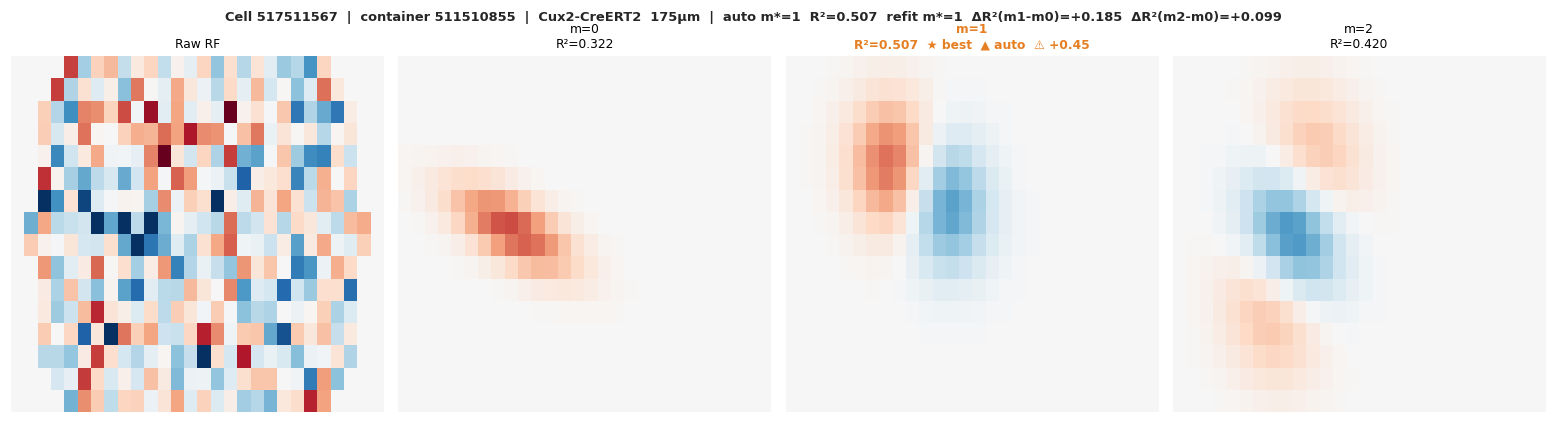

In [14]:
# ---------------------------------------------------------------------------
# SHOW CELL — re-run to advance
# Default: keep m=1 (that's what the automated v2 call said).
# Change M_ACCEPT=0 in RECORD cell if it looks like a blob.
# ---------------------------------------------------------------------------
row     = unrev_review_df.iloc[UNREV_IDX]
cid     = int(row['cell_id'])
rf_map, pix = unrev_rf_cache[cid]

print(f'--- {UNREV_IDX+1}/{len(unrev_review_df)} ---  cell {cid}  '
      f'R²={row["r_squared"]:.3f}  ΔR²vs_m0={row["delta_r2_vs_m0"]:.3f}')

_fit_cache = refit_all_orders(rf_map, pix, seed=cid)
r2s   = {m: _fit_cache[m][1]['r_squared'] for m in [0,1,2]}
r2_m0 = r2s[0] if not np.isnan(r2s[0]) else 0.0

for m in [0,1,2]:
    p   = _fit_cache[m][0]
    imp = p.get('r2_improvement', 0) if p else 0
    warn = ' ⚠ local-min' if imp > 0.05 else ''
    print(f'  m={m}  R²={r2s[m]:.3f}{warn}')
print(f'ΔR²(m1-m0)={r2s[1]-r2_m0:+.3f}   ΔR²(m2-m0)={r2s[2]-r2_m0:+.3f}')
print(f'Default: keep m=1  →  set M_ACCEPT=0 in RECORD cell to demote')

fig = plot_neuron_review(cid, rf_map, _fit_cache, 1, pix,
                         {**row.to_dict(), '_force_best': 1})
plt.tight_layout()
plt.show()

In [15]:
# ---------------------------------------------------------------------------
# RECORD CELL — set M_ACCEPT then run, then re-run SHOW CELL
# ---------------------------------------------------------------------------
M_ACCEPT = 1    # ← change to 0 if blob
NOTE     = ''   # ← optional

row = unrev_review_df.iloc[UNREV_IDX]
cid = int(row['cell_id'])

new_row       = pd.DataFrame([{'cell_id': cid, 'm_manual': M_ACCEPT, 'note': NOTE}])
unrev_judged  = pd.concat(
    [unrev_judged[unrev_judged['cell_id'] != cid], new_row],
    ignore_index=True
)
unrev_judged_ids = set(unrev_judged['cell_id'].tolist())
unrev_judged.to_csv(UNREV_JUDGEMENT_CSV, index=False)

done     = len(unrev_judged_ids)
accepted = int((unrev_judged['m_manual'] == 1).sum())
print(f'✓ cell {cid}  m={M_ACCEPT}  '
      f'({done}/{len(unrev_review_df)}  |  {accepted} accepted m=1 so far)')

UNREV_IDX = _first_unrev_unjudged(UNREV_IDX + 1)
print(f'Next: {UNREV_IDX}  →  re-run SHOW CELL')

✓ cell 517511567  m=1  (1/1  |  1 accepted m=1 so far)
Next: 0  →  re-run SHOW CELL


In [8]:
# ---------------------------------------------------------------------------
# STEP 2: Identify m=0 rescue candidates
#
# These are neurons currently m_final==0 (automated or manual) where
# the v2 rerun's r2_m1 is already within striking distance — worth checking
# whether higher smoothing unlocks a convincing m=1 fit.
#
# Filter criteria (generous — we want to cast a wide net for rescue):
#   - m_final == 0 AND not manually confirmed as m=0 in nb07/nb09
#   - r2_m1 exists and is within 0.08 of r2_m0 (close contest)
#   - r_squared >= 0.30 (map has some signal)
#
# Expected: ~100-150 candidates. All will be screened by the smoothing fit
# and only those where m=1 wins with ΔR²>0.05 at ANY sigma proceed to
# visual review.
# ---------------------------------------------------------------------------
RESCUE_GAP      = 0.08   # r2_m1 within this of r2_m0
RESCUE_MIN_R2   = 0.30
RESCUE_DELTA_ACCEPT = 0.05   # ΔR²>this at any sigma → show for review

# Neurons manually confirmed as m=0 — do not re-examine
confirmed_m0 = set(cid for cid, m in judged.items() if m == 0)

if 'r2_m1' in all_df.columns:
    rescue_pool = all_df[
        (all_df['m_final'] == 0) &
        (~all_df['cell_id'].isin(confirmed_m0)) &
        (all_df['r_squared'] >= RESCUE_MIN_R2) &
        (all_df['r2_m1'].notna()) &
        ((all_df['r2_m0'] - all_df['r2_m1']).abs() <= RESCUE_GAP)
    ].copy()
else:
    # If r2_m1 not in CSV fall back to all unconfirmed m=0 with decent R²
    rescue_pool = all_df[
        (all_df['m_final'] == 0) &
        (~all_df['cell_id'].isin(confirmed_m0)) &
        (all_df['r_squared'] >= RESCUE_MIN_R2)
    ].copy()
    print('Warning: r2_m1 column not found — using all unconfirmed m=0 neurons')

rescue_pool = rescue_pool.sort_values('r_squared', ascending=False).reset_index(drop=True)

print(f'Rescue pool: {len(rescue_pool)} m=0 neurons to screen with smoothing')
print(f'  (excludes {len(confirmed_m0)} manually confirmed m=0)')
if 'r2_m1' in all_df.columns:
    print(f'  r2_m1 range: {rescue_pool["r2_m1"].min():.3f}–'
          f'{rescue_pool["r2_m1"].max():.3f}')

Rescue pool: 291 m=0 neurons to screen with smoothing
  (excludes 350 manually confirmed m=0)
  r2_m1 range: 0.218–0.823


In [18]:
# ---------------------------------------------------------------------------
# Load RF maps for rescue pool — per container with progress
# ---------------------------------------------------------------------------
rf_map_cache  = {}
dataset_cache = {}

by_container = rescue_pool.groupby('container_id')['cell_id'].apply(list).to_dict()
print(f'Loading {len(rescue_pool)} neurons across {len(by_container)} containers')
print()

t_start = time.time()
for i, (container_id, cids) in enumerate(by_container.items()):
    if container_id not in container_to_exp:
        print(f'  [{i+1}/{len(by_container)}] {container_id}: skip')
        continue
    print(f'  [{i+1}/{len(by_container)}] Container {container_id} '
          f'({len(cids)} neurons) ...', end=' ', flush=True)
    try:
        if container_id not in dataset_cache:
            dataset_cache[container_id] = boc.get_ophys_experiment_data(
                container_to_exp[container_id])
        maps = batch_get_rf_maps_safe(dataset_cache[container_id], cids)
        rf_map_cache.update(maps)
        print(f'{len(maps)} loaded  ({time.time()-t_start:.0f}s)')
    except Exception as e:
        print(f'FAIL — {e}')

print(f'\nTotal RF maps loaded: {len(rf_map_cache)}')

Loading 291 neurons across 17 containers

  [1/17] Container 511507650 (23 neurons) ... 23 loaded  (75s)
  [2/17] Container 511509529 (19 neurons) ... 19 loaded  (137s)
  [3/17] Container 511510650 (7 neurons) ... 7 loaded  (198s)
  [4/17] Container 511510670 (22 neurons) ... 22 loaded  (264s)
  [5/17] Container 511510718 (13 neurons) ... 13 loaded  (328s)
  [6/17] Container 511510736 (8 neurons) ... 8 loaded  (392s)
  [7/17] Container 511510855 (12 neurons) ... 12 loaded  (451s)
  [8/17] Container 650389885 (13 neurons) ... 13 loaded  (507s)
  [9/17] Container 652842570 (15 neurons) ... 15 loaded  (558s)
  [10/17] Container 653125128 (17 neurons) ... 17 loaded  (610s)
  [11/17] Container 661437138 (12 neurons) ... 12 loaded  (670s)
  [12/17] Container 661732156 (27 neurons) ... 27 loaded  (725s)
  [13/17] Container 666589599 (15 neurons) ... 15 loaded  (783s)
  [14/17] Container 680156909 (19 neurons) ... 19 loaded  (840s)
  [15/17] Container 682734790 (17 neurons) ... 17 loaded  (895

In [19]:
# ---------------------------------------------------------------------------
# Fitting helpers
# ---------------------------------------------------------------------------
_MODEL_FNS      = {0: gaussian_deriv_m0, 1: gaussian_deriv_m1, 2: gaussian_deriv_m2}
N_RANDOM_STARTS = 15


def fit_two_stage(rf_map, pix, smooth_sigma, m=1, seed=None):
    """Stage 1 at smooth_sigma, stage 2 refit at sigma=0.75 if sigma>0.75."""
    rf_on  = np.maximum(rf_map,  0.0)
    rf_off = np.maximum(-rf_map, 0.0)
    grid_h, grid_w = rf_map.shape
    Y, X = np.mgrid[0:grid_h, 0:grid_w].astype(float)
    xy   = (X, Y)

    p1, q1 = fit_rf_by_order(
        rf_on, rf_off, m=m, pixel_size_deg=pix,
        smooth_sigma=smooth_sigma,
        n_random_starts=N_RANDOM_STARTS, seed=seed,
    )

    if q1['converged'] and smooth_sigma > 0.75:
        p_f, q_f = fit_rf_by_order(
            rf_on, rf_off, m=m, pixel_size_deg=pix,
            smooth_sigma=0.75, n_random_starts=0, seed=seed,
        )
    else:
        p_f, q_f = p1, q1

    su_px = p_f['sigma_x'] / pix
    sv_px = p_f['sigma_y'] / pix
    x0_px = p_f['x0']     / pix
    y0_px = p_f['y0']     / pix
    th_r  = np.deg2rad(p_f['theta'])
    popt  = [p_f['amplitude'], x0_px, y0_px, su_px, sv_px, th_r, 0.0]
    fitted = _MODEL_FNS[m](xy, *popt).reshape(grid_h, grid_w)
    return p_f, q_f, fitted


def run_rescue_fits(rf_map, pix, seed=None):
    """Fit m=0 (ref) and m=1 at sigma=0.75, 1.0, 1.5."""
    rng     = np.random.default_rng(seed)
    results = {}
    # m=0 reference at sigma=0.75
    s = int(rng.integers(0, 2**31))
    try:
        p, q, f = fit_two_stage(rf_map, pix, 0.75, m=0, seed=s)
        results['m0_ref'] = (p, q, f)
    except Exception as e:
        results['m0_ref'] = (None, {'r_squared': np.nan, 'converged': False,
                                     'message': str(e)}, None)
    # m=1 at three sigma values
    for sigma in [0.75, 1.0, 1.5]:
        s = int(rng.integers(0, 2**31))
        try:
            p, q, f = fit_two_stage(rf_map, pix, sigma, m=1, seed=s)
            results[f'm1_s{sigma}'] = (p, q, f)
        except Exception as e:
            results[f'm1_s{sigma}'] = (None, {'r_squared': np.nan,
                                               'converged': False,
                                               'message': str(e)}, None)
    return results


def best_m1_r2(results):
    """Return the best m=1 R² across all three sigma values."""
    r2s = [results[f'm1_s{s}'][1]['r_squared'] for s in [0.75, 1.0, 1.5]]
    valid = [r for r in r2s if not np.isnan(r)]
    return max(valid) if valid else np.nan


def plot_rescue(cid, rf_map, results, row_info):
    """5-panel: Raw RF | m=0 ref | m=1 σ=0.75 | m=1 σ=1.0 | m=1 σ=1.5"""
    r2_m0 = results['m0_ref'][1]['r_squared']
    r2_m1 = {s: results[f'm1_s{s}'][1]['r_squared'] for s in [0.75, 1.0, 1.5]}
    best_s = max([0.75, 1.0, 1.5],
                  key=lambda s: r2_m1[s] if not np.isnan(r2_m1[s]) else -np.inf)
    best_delta = r2_m1[best_s] - r2_m0

    cre   = str(row_info.get('cre_line', ''))[:20]
    depth = row_info.get('depth_um', '')

    fig = plt.figure(figsize=(22, 4.2))
    gs  = gridspec.GridSpec(1, 5, figure=fig, wspace=0.04)
    fig.suptitle(
        f'Cell {cid}  |  {cre}  {depth}μm  |  '
        f'orig R²={row_info.get("r_squared",0):.3f}  |  '
        f'm=0: {r2_m0:.3f}  |  '
        f'm=1: σ=0.75→{r2_m1[0.75]:.3f}  σ=1.0→{r2_m1[1.0]:.3f}  '
        f'σ=1.5→{r2_m1[1.5]:.3f}  |  best ΔR²={best_delta:+.3f}',
        fontsize=8, fontweight='bold'
    )

    vmax = np.nanpercentile(np.abs(rf_map), 98)
    imkw = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                aspect='auto', origin='lower', interpolation='nearest')

    # Raw RF
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(rf_map, **imkw)
    ax.set_title('Raw RF', fontsize=8); ax.axis('off')

    # m=0 reference
    ax = fig.add_subplot(gs[0, 1])
    _, _, f0 = results['m0_ref']
    if f0 is not None:
        ax.imshow(f0, **imkw)
    else:
        ax.set_facecolor('#333')
    ax.set_title(f'm=0  σ=0.75\nR²={r2_m0:.3f}',
                 fontsize=8, color='#4CAF50'); ax.axis('off')

    # m=1 at each sigma
    for col_i, sigma in enumerate([0.75, 1.0, 1.5], start=2):
        ax = fig.add_subplot(gs[0, col_i])
        _, q, f = results[f'm1_s{sigma}']
        if f is not None:
            ax.imshow(f, **imkw)
        else:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'failed', color='white',
                    ha='center', va='center', transform=ax.transAxes)
        r2    = r2_m1[sigma]
        delta = r2 - r2_m0
        stage = ' (stage-2)' if sigma > 0.75 else ''
        best_flag = ' ★' if sigma == best_s else ''
        bold  = (sigma == best_s and best_delta > RESCUE_DELTA_ACCEPT)
        ax.set_title(
            f'm=1  σ={sigma}{stage}\nR²={r2:.3f}  Δ={delta:+.3f}{best_flag}',
            fontsize=8,
            fontweight='bold' if bold else 'normal',
            color='#e67e22' if bold else 'black'
        )
        ax.axis('off')

    return fig


print('Helpers defined.')

Helpers defined.


In [20]:
# ---------------------------------------------------------------------------
# STEP 3: Screen rescue pool with smoothing fits
# Run multi-sigma fits on all rescue pool neurons and keep only those where
# m=1 wins by ΔR²>0.05 at ANY sigma — these go to visual review.
# Everything else stays m=0 without visual review.
#
# This is the slow cell (~5-8 min per container already loaded above)
# ---------------------------------------------------------------------------
SCREEN_CSV = nb05d_dir / 'rescue_screen_results.csv'

if SCREEN_CSV.exists():
    screen_df = pd.read_csv(SCREEN_CSV)
    print(f'Loaded cached screen results: {len(screen_df)} neurons')
else:
    screen_rows = []
    n_total = len(rescue_pool[rescue_pool['cell_id'].isin(rf_map_cache)])
    print(f'Screening {n_total} neurons with smoothing fits ...')
    t0 = time.time()

    for idx, row in rescue_pool.iterrows():
        cid = int(row['cell_id'])
        if cid not in rf_map_cache:
            continue
        rf_map, pix = rf_map_cache[cid]
        res = run_rescue_fits(rf_map, pix, seed=cid)

        r2_m0  = res['m0_ref'][1]['r_squared']
        r2_m1s = {s: res[f'm1_s{s}'][1]['r_squared'] for s in [0.75, 1.0, 1.5]}
        best_s = max([0.75,1.0,1.5],
                      key=lambda s: r2_m1s[s] if not np.isnan(r2_m1s[s]) else -np.inf)
        best_r2   = r2_m1s[best_s]
        best_delta = best_r2 - r2_m0
        passes = bool(best_delta > RESCUE_DELTA_ACCEPT)

        screen_rows.append({
            'cell_id':      cid,
            'container_id': int(row['container_id']),
            'r2_orig':      float(row['r_squared']),
            'r2_m0_refit':  float(r2_m0),
            'r2_m1_075':    float(r2_m1s[0.75]),
            'r2_m1_100':    float(r2_m1s[1.0]),
            'r2_m1_150':    float(r2_m1s[1.5]),
            'best_sigma':   float(best_s),
            'best_delta':   float(best_delta),
            'passes_screen': passes,
        })

        if (len(screen_rows) % 20 == 0):
            print(f'  {len(screen_rows)}/{n_total}  '
                  f'({time.time()-t0:.0f}s)  '
                  f'passing so far: {sum(r["passes_screen"] for r in screen_rows)}')

    screen_df = pd.DataFrame(screen_rows)
    screen_df.to_csv(SCREEN_CSV, index=False)
    print(f'\nScreening done in {(time.time()-t0)/60:.1f} min')

n_pass = screen_df['passes_screen'].sum()
print(f'\nScreening results:')
print(f'  Screened: {len(screen_df)}')
print(f'  Pass (ΔR²>{RESCUE_DELTA_ACCEPT} at any sigma): {n_pass}')
print(f'  Fail → stay m=0: {len(screen_df) - n_pass}')
print(f'  best_delta distribution (passing):')
passing = screen_df[screen_df['passes_screen']]
print(passing['best_delta'].describe().round(3))

Screening 291 neurons with smoothing fits ...
  20/291  (36s)  passing so far: 0
  40/291  (67s)  passing so far: 0
  60/291  (107s)  passing so far: 0
  80/291  (147s)  passing so far: 0
  100/291  (173s)  passing so far: 0
  120/291  (196s)  passing so far: 0
  140/291  (231s)  passing so far: 0
  160/291  (256s)  passing so far: 0
  180/291  (280s)  passing so far: 0
  200/291  (304s)  passing so far: 0
  220/291  (332s)  passing so far: 0
  240/291  (358s)  passing so far: 0
  260/291  (382s)  passing so far: 0
  280/291  (404s)  passing so far: 0

Screening done in 6.9 min

Screening results:
  Screened: 291
  Pass (ΔR²>0.05 at any sigma): 0
  Fail → stay m=0: 291
  best_delta distribution (passing):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: best_delta, dtype: float64


In [ ]:
# ---------------------------------------------------------------------------
# Set up visual review of passing neurons
# ---------------------------------------------------------------------------
passing_ids  = set(screen_df[screen_df['passes_screen']]['cell_id'].tolist())
review_df = rescue_pool[
    rescue_pool['cell_id'].isin(passing_ids) &
    rescue_pool['cell_id'].isin(rf_map_cache)
].copy()

# Merge screen results
review_df = review_df.merge(screen_df[['cell_id','best_delta','best_sigma',
                                         'r2_m0_refit','r2_m1_075',
                                         'r2_m1_100','r2_m1_150']],
                              on='cell_id', how='left')
review_df = review_df.sort_values('best_delta', ascending=False).reset_index(drop=True)

# Load or init judgement store
if RESCUE_JUDGEMENT_CSV.exists():
    rescue_judged     = pd.read_csv(RESCUE_JUDGEMENT_CSV)
    rescue_judged_ids = set(rescue_judged['cell_id'].tolist())
    print(f'Loaded {len(rescue_judged)} existing rescue judgements')
else:
    rescue_judged     = pd.DataFrame(columns=['cell_id', 'm_final', 'note'])
    rescue_judged_ids = set()
    print('Fresh rescue judgement store.')


def _first_unjudged(start=0):
    for i in range(start, len(review_df)):
        if int(review_df.iloc[i]['cell_id']) not in rescue_judged_ids:
            return i
    return len(review_df) - 1


if 'RESCUE_IDX' not in dir():
    RESCUE_IDX = _first_unjudged()

print(f'\nFor visual review: {len(review_df)} neurons  '
      f'(sorted by best ΔR², largest first)')
print(f'Already judged: {len(rescue_judged_ids)}')
print(f'Starting at index: {RESCUE_IDX}')

In [ ]:
# ---------------------------------------------------------------------------
# SHOW CELL — re-run to advance
# Default is m=1 (that's why it passed the screen). Demote to 0 if blob.
# ---------------------------------------------------------------------------
row     = review_df.iloc[RESCUE_IDX]
cid     = int(row['cell_id'])
rf_map, pix = rf_map_cache[cid]

print(f'--- {RESCUE_IDX+1}/{len(review_df)} ---  cell {cid}  '
      f'orig R²={row["r_squared"]:.3f}  best ΔR²={row["best_delta"]:+.3f}  '
      f'best σ={row["best_sigma"]}')
print(f'  m=0 refit: {row["r2_m0_refit"]:.3f}   '
      f'm=1: σ=0.75→{row["r2_m1_075"]:.3f}  '
      f'σ=1.0→{row["r2_m1_100"]:.3f}  '
      f'σ=1.5→{row["r2_m1_150"]:.3f}')

if cid in rescue_judged_ids:
    prev = rescue_judged[rescue_judged['cell_id'] == cid].iloc[-1]
    print(f'↩ Previously: m={prev["m_final"]}  note="{prev["note"]}"')

_rescue_results = run_rescue_fits(rf_map, pix, seed=cid)
_rescue_default = 1   # default: accept as m=1 (it passed the screen)
print(f'Default: M_FINAL=1  →  change to 0 in RECORD cell if it looks like a blob')

fig = plot_rescue(cid, rf_map, _rescue_results, row.to_dict())
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# RECORD CELL — set M_FINAL then run, then re-run SHOW CELL
# ---------------------------------------------------------------------------
M_FINAL = _rescue_default   # ← change to 0 if blob
NOTE    = ''                # ← optional

row = review_df.iloc[RESCUE_IDX]
cid = int(row['cell_id'])

new_row       = pd.DataFrame([{'cell_id': cid, 'm_final': M_FINAL, 'note': NOTE}])
rescue_judged = pd.concat(
    [rescue_judged[rescue_judged['cell_id'] != cid], new_row],
    ignore_index=True
)
rescue_judged_ids = set(rescue_judged['cell_id'].tolist())
rescue_judged.to_csv(RESCUE_JUDGEMENT_CSV, index=False)

done = len(rescue_judged_ids)
accepted = int((rescue_judged['m_final'] == 1).sum())
print(f'✓ Saved  cell {cid}  m={M_FINAL}  '
      f'({done}/{len(review_df)} done  |  {accepted} accepted as m=1 so far)')

RESCUE_IDX = _first_unjudged(RESCUE_IDX + 1)
print(f'Next: index {RESCUE_IDX}  →  re-run SHOW CELL')

In [ ]:
# ---------------------------------------------------------------------------
# FINAL MERGE — combine restored m=1 + rescued m=1 → save clean final CSV
# ---------------------------------------------------------------------------
rescue_judged = pd.read_csv(RESCUE_JUDGEMENT_CSV)
rescue_lookup = dict(zip(rescue_judged['cell_id'].astype(int),
                          rescue_judged['m_final'].astype(int)))

# Start from the restored all_df (84-neuron m=1)
# Apply rescue judgements on top
n_rescued = 0
for cid, m_new in rescue_lookup.items():
    mask = all_df['cell_id'] == cid
    if mask.any():
        old_m = int(all_df.loc[mask, 'm_final'].values[0])
        all_df.loc[mask, 'm_final'] = m_new
        if old_m == 0 and m_new == 1:
            n_rescued += 1

m1_final = all_df[all_df['m_final'] == 1]

print(f'Restored m=1 (from nb07+nb09): {len(m1_restored)}')
print(f'Newly rescued m=1 (smoothing): {n_rescued}')
print(f'\nFinal m_final breakdown:')
print(all_df['m_final'].value_counts().sort_index())
print(f'\nFinal m=1: {len(m1_final)}')
print(m1_final[['sigma','kappa','r_squared']].describe().round(3))

all_df.to_csv(FINAL_CSV, index=False)
print(f'\nSaved → {FINAL_CSV}')